# Consigna

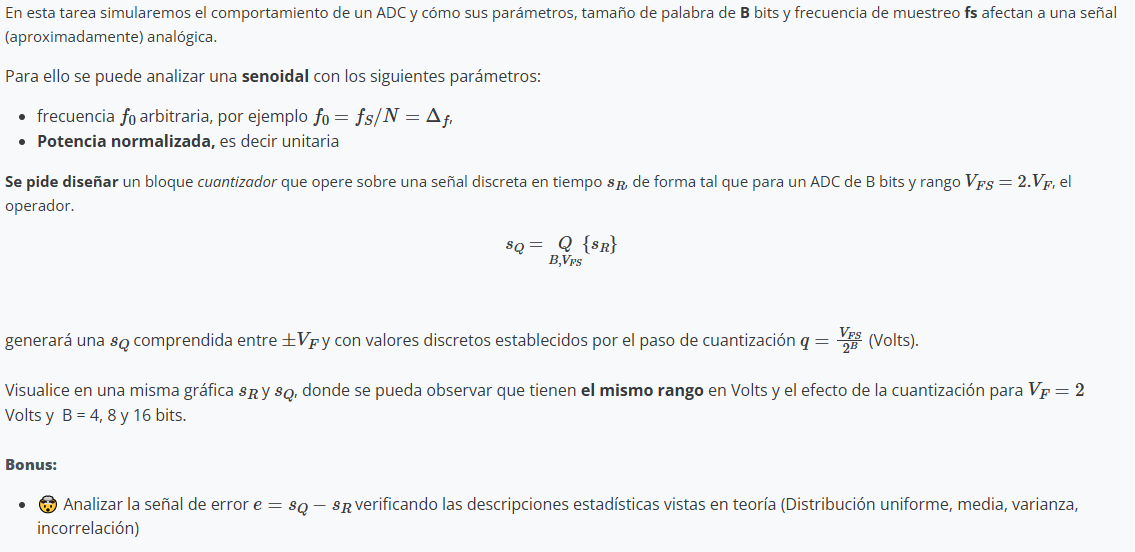

# Funciones Previas

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

In [10]:
import numpy as np
import matplotlib.pyplot as plt

def mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = vmax * np.sin(2*np.pi*ff*tt + ph) + dc
    xx = np.array(xx).reshape(nn,1)
    tt = tt.reshape(nn,1)

    return xx, tt

def mi_funcion_cuadrada(vmax = 1, dc = 0, ff = 1, duty = .5, nn = 100, fs = 1000 ) -> tuple[np.ndarray,np.ndarray] :
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.where(tt % (1/ff) < (1/ff) * duty, 1, -1)
    xx = vmax * xx + dc
    #signal.square(2* np.pi * ff* tt, duty)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_funcion_triangular(vmax = 1, dc = 0, ff = 1, nn = 1, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    ts = 1/fs
    tt: np.ndarray = np.arange(stop= nn*ts, step=ts)
    T = 1/ff

    xx = [((vmax/T) * (i%T) + dc) for i in tt]
    #signal.sawtooth(2* np.pi * ff* tt, 0.5)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
    '''noise_generator(var = 1, nn = 100, fs = 1000) -> tuple[np.ndarray,np.ndarray]:
        Generates Gaussian noise, with variance var and zero mean.

        Note: This distribution corresponds to "white noise". (Extracted from ASYS notes, Stochastic process - White Noise)
    '''
    ts = 1/fs
    tt: np.ndarray = np.arange(stop=nn*ts, step=ts)

    xx = np.random.normal(loc=0, scale=np.sqrt(var), size=nn)

    tt = tt.reshape(nn,1)
    xx = np.array(xx).reshape(nn,1)

    return xx, tt

def mi_sen_ruidosa( vmax = 1, dc = 0, ff = 1, ph = 0, nn = 100, fs = 1000, snr = 20) -> tuple[np.ndarray,np.ndarray]:
    xx, tt = mi_funcion_sen(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs)
    pot_signal = np.mean(xx**2)
    var_noise = pot_signal / (10**(snr/10))  # Calculando potencia de señal conocida "senoidal"
    # var_noise = power(xx) / (10**(snr/10))    # Lo mismo, calculando potencia por definicion
    
    noise, _ = noise_generator(var_noise, nn, fs)
    xx = xx + noise

    return xx, tt

def power(x: np.ndarray) -> float:
    '''power(x: np.ndarray) -> float:
        Returns the power of the signal x, defined as the mean of the square of the Voltage signal. 
    '''
    return np.mean(np.mean(x)**2)

def snr(signal: np.ndarray, noise: np.ndarray) -> float:
    return 10 * np.log10(np.mean(signal**2) / np.mean(noise**2))

def mod_db(xx: np.ndarray) -> np.ndarray:
    return 20*np.log10(np.abs(xx))

def mod_dbw(xx: np.ndarray) -> np.ndarray:
    return 10*np.log10(np.abs(xx))

def freq_axis(xx: np.ndarray, fs: float) -> np.ndarray:
    '''freq_axis
    
    Equal to np.fft.fftfreq. It generates the correct freq axis for the fft algorithm.
    Axis has the form:
    [0, △f, 2△f, ..., fs/2, -fs/2, -(fs/2-△f), ..., -△f]
    Note: the positive half always starts with 0. The negative half always starts with -fs/2, so, the negative half has one extra value if the length of the signal is even.
    xx: signal to generate the axis for. Only the length is used.
    fs: sampling frequency
    '''
    nn = xx.shape[0]
    half = np.arange(0, fs/2, fs/nn)
    ff = np.concatenate((half, -half[::-1] - fs/nn))
    ff = ff[:nn]
    return ff.reshape(-1,1)

# Respuesta

Funciones de resoluciones anteriores. Para un uso correcto deberían guardarse en un archivo Python (.py) en una carpeta lib para utilización como librerías. 

A fines prácticos, se copiarán acá

## Funcion

Funciones definidas para este ejercicio

La primera simulará el comportamiento de un ADC. El ADC pasa de infinitos valores posibles que puede tomar nuestra señal a N valores. Esto, se puede ver como que se le añadió a la función que se desea medir un "ruido" perfectamente colocado para que las muestras presenten un rango finito de valores.

La segunda funcion realiza la autocorrelación de una función. Esto corresponde a la PSD (Densidad Espectral de Potencia) de una señal ya que ambas definiciones son iguales. Se utilizará para obtener la PSD del ruido añadido por el ADC.

In [11]:
def mi_adc(xx, Vfs, bits=4):
    '''
    Cuantizador que simula el comportamiento de un ADC
    xx: Señal a convertir
    Vfs: ADC [0, Vfs]
    bits: cantidad de Bits.
    ''' 
    q = Vfs/(2**bits) 
    xd = np.round(xx/q) * q
    vmax =  q*(2**(bits-1)-1)
    vmin = -q*2**(bits-1)

    np.clip(xd, vmin, vmax, out=xd)
    #xd[xd > vmax] = vmax
    #xd[xd < vmin] = vmin
    return xd

def autocorrelate(xx):
    xx = np.asarray(xx).flatten()

    autocorr = np.correlate(xx, xx, mode='full')/xx.size        # Normalizated to size. Gives the true values of the autocorrelation
    autocorr = autocorr[autocorr.size//2:]                      # Only keep non negative values
    autocorr = autocorr.reshape(-1,1)                           # Reshape to column vector (standard of PDS)
    return autocorr
    

## Prueba 1:

Se realiza una prueba con una señal senoidal normalizada a 1W, pasada por un ADC.

In [12]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

VFS = 4
bits = 4

##### Funciones
xx, t = mi_funcion_sen(vmax, ff=freq, ph=ph,  nn=N, fs=fs)
xq = mi_adc(xx, VFS, bits)
error = xx - xq
autocorr_error = autocorrelate(error)


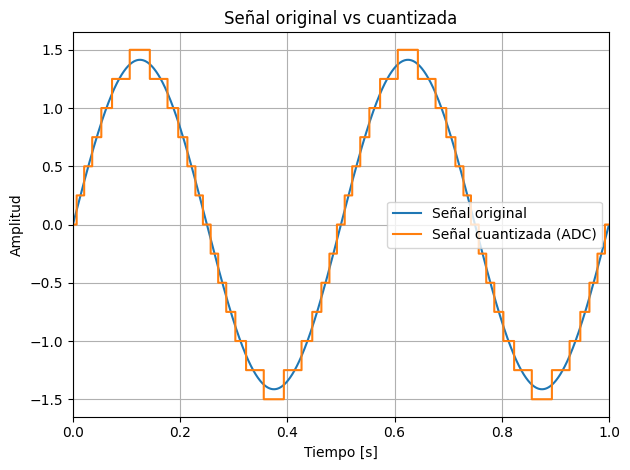

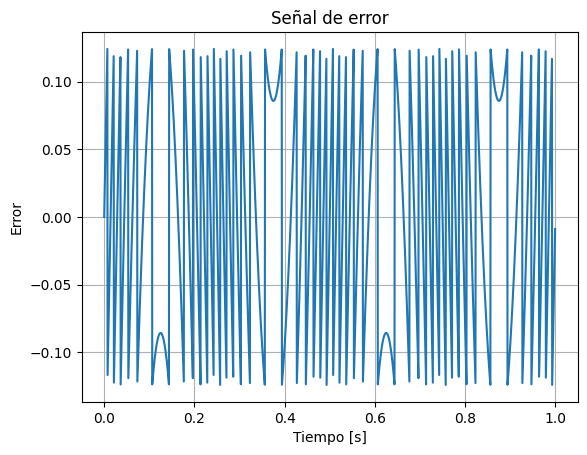

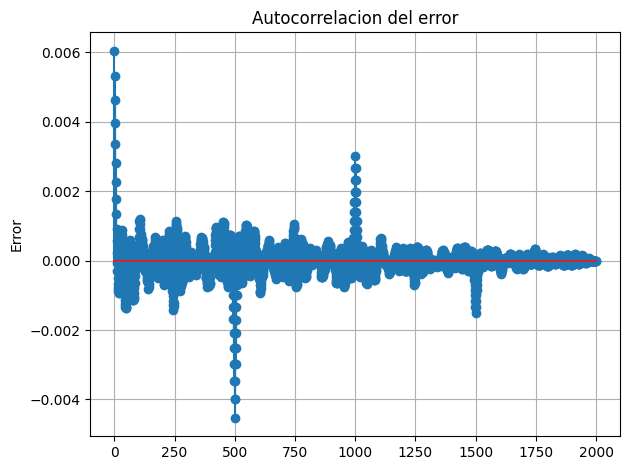

Varianza: 0.00604
Potencia de autocorrelacion: 0.00604
Cálculo matemático Señal Uniforme (q^2/12): 0.00521


In [13]:
##### Gráficos ADC
x_max = 2/freq

plt.figure()
plt.plot(t, xx, label="Señal original")
plt.step(t, xq, label="Señal cuantizada (ADC)")
plt.xlim([0, x_max])
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal original vs cuantizada")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


##### Gráficos error ADC
plt.figure()
plt.plot(t, error)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.title("Señal de error")
plt.grid()

plt.show()

##### Autocrrelación de Error
plt.figure()
plt.stem(autocorr_error)
plt.ylabel("Error")
plt.title("Autocorrelacion del error")
plt.grid()
plt.tight_layout()
plt.show()

##### Cálculos Potencia de señal de error
print(f"Varianza: {np.var(error, axis=0)[0]:.3g}")
print(f"Potencia de autocorrelacion: {autocorr_error[0][0]:.3g}")
q = VFS/2**bits
print(f"Cálculo matemático Señal Uniforme (q^2/12): {q**2/12:.3g}")


Se puede observar en los gráficos cómo la señal original sufrió cambios al pasar por el ADC (se escalonó). 
En el 2do y 3er gráfico se observa ese error entre señales en el dominio del tiempo y de la frecuencia utilizando la autocorrelación para obtener la PSD.

Se calcula la varianza de la señal de error con 3 métodos distintos. El primero calcula la varianza de la señal de forma directa, el segundo la obtiene como el valor 0 de la PSD de la señal y el último lo calcula de fórma teórica utilizando la fórmula definida para el error del ADC. Se observa que esta última difiere levemente y es de esperar, puesto que la fórmula asume cosas que quizá no estén ocurriendo realmente.

## Prueba 2: 

Senoidal con ruido
Se analizan ahora los efectos de la densidad espectral de potencia (PSD).

Nota: La PSD, por definición, se puede calcular como la transformada de fourier de la autocorrelación. Esta definición se utilizará para obtener la PSD de un proceso estocástico (Ruido).


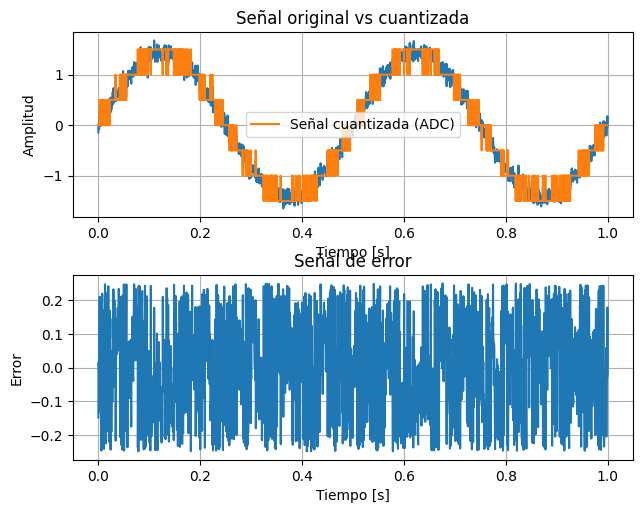

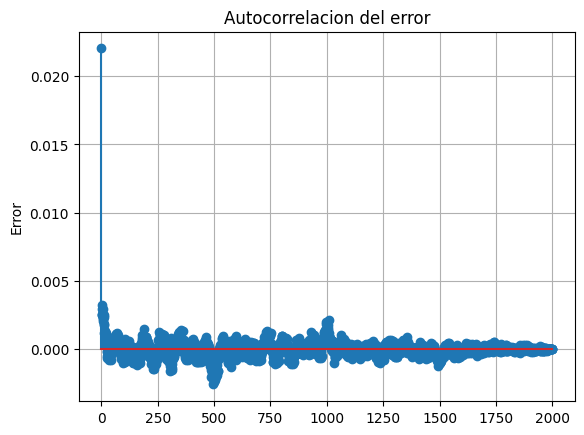

Varianza: 0.022
Potencia de Autocorrelacion: 0.022
Cálculo Matemático Señal Uniforme (q^2/12): 0.0208


In [14]:
##### Variables
vmax = 2**.5    # Vpico
ph = 0          # Fase inicial
N = 2000        # Cant Muestras
fs = 2000       # Freq muestreo

delta_f = fs/N
freq = 2*delta_f    # Freq

VFS = 4 
bits = 3

##### Funciones
xx, t = mi_sen_ruidosa(vmax, ff=freq, ph=ph, nn=N, fs=fs, snr=20)
xq = mi_adc(xx, VFS, bits)

error = xx - xq
autocorr_error = autocorrelate(error)
psd_error_q = np.fft.fft(autocorr_error, axis=0)/autocorr_error.size
abs_psd_error = np.abs(psd_error_q)

xx_fft = np.fft.fft(xx, axis=0)/xx.size
abs_xx_fft = np.abs(xx_fft)

xq_fft = np.fft.fft(xq, axis=0)/xq.size
abs_xq_fft = np.abs(xq_fft)


##### Gráficos
plt.figure()
plt.subplot(2,1,1)
plt.plot(t, xx)
plt.step(t, xq, label="Señal cuantizada (ADC)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Señal original vs cuantizada")
plt.legend()
plt.tight_layout()
plt.grid()

# Señal de Error #####
plt.subplot(2,1,2)
plt.plot(t, error)
plt.xlabel("Tiempo [s]")
plt.ylabel("Error")
plt.title("Señal de error")
plt.grid()
plt.show()


# Señal de Error #####
plt.figure()
plt.stem((autocorr_error))
plt.ylabel("Error")
plt.title("Autocorrelacion del error")
plt.grid()
plt.show()

print(f"Varianza: {np.var(error, axis=0)[0]:.3g}")
print(f"Potencia de Autocorrelacion: {autocorr_error[0][0]:.3g}")
q = VFS/2**bits
print(f"Cálculo Matemático Señal Uniforme (q^2/12): {q**2/12:.3g}")


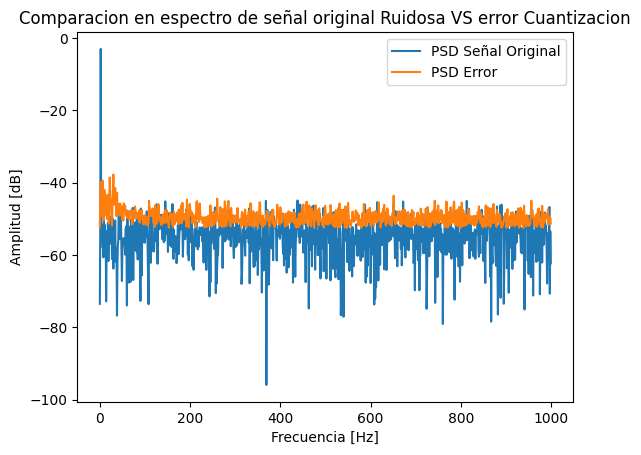

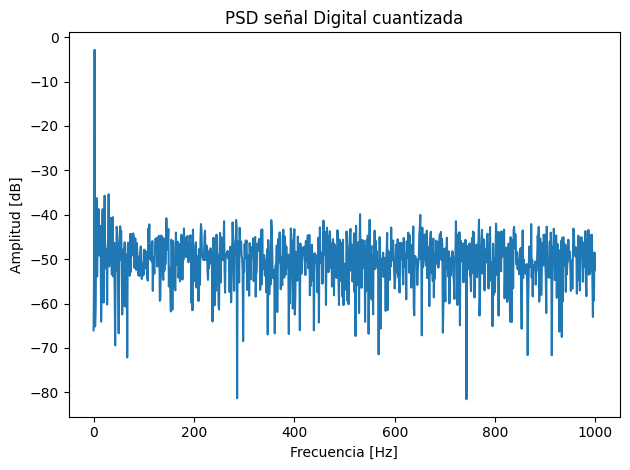

In [15]:
plt.figure()
plt.plot(20*np.log10(abs_xx_fft)[0:len(abs_xx_fft)//2], label='PSD Señal Original')
plt.plot(10*np.log10(abs_psd_error)[0:len(abs_psd_error)//2], label='PSD Error')
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.title("Comparacion en espectro de señal original Ruidosa VS error Cuantizacion")
plt.legend()
plt.show()

plt.figure()
plt.plot(20*np.log10(np.maximum(abs_xq_fft, 1e-12))[0:len(abs_xq_fft)//2])       # 20, es señal de tension
plt.title("PSD señal Digital cuantizada")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [dB]")
plt.tight_layout()
plt.show()


Cambiando el número de bits y el snr de la señal senoidal se pueden modificar los pisos de ruido correspondientes.
Como el ruido de cuantización es independiente del ruido de la señal, sus PSD no se suman y el piso de ruido resultante será el peor de ambos.
Si elijo muchos bits, llego a un límite de ruido impuesto por la señal de entrada.
Si elijo pocos bits, el piso de ruido se deberá por completo a la cuantización. 

Una señal real se "aparea" con el ADC cuando el número de bits genera un piso de ruido igual al de la señal de entrada. Se logra el mínimo ruido posible.


## Prueba 3:

Comparación de señal original con ruido y ruido del ADC

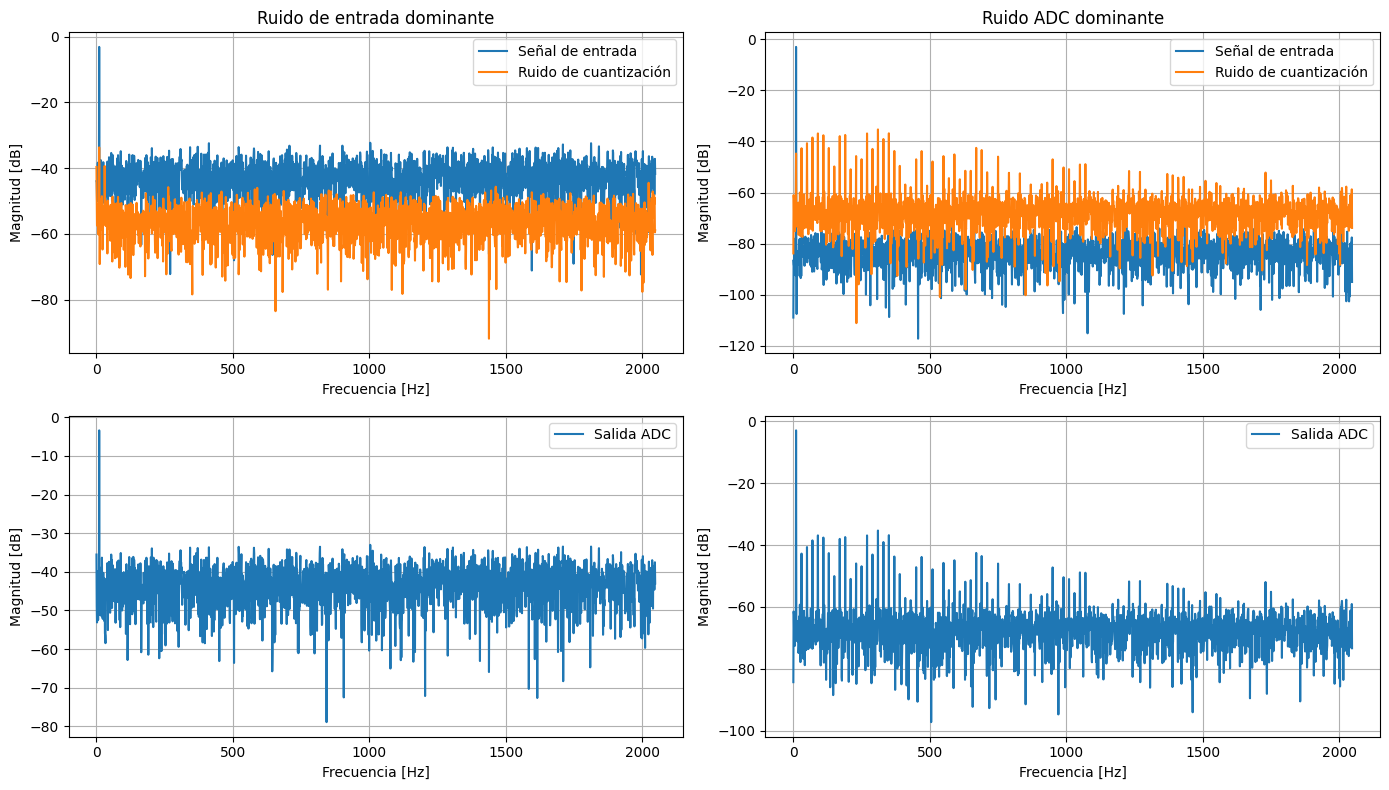

In [25]:
import numpy as np
import matplotlib.pyplot as plt

##### Variables

vmax = 2**0.5

N = 4096
fs = 4096

freq = 10

VFS = 4
bits = 4

snr_cases = [
    ("Ruido de entrada dominante", 5),    # mucho ruido analógico
    ("Ruido ADC dominante", 45)        # poco ruido analógico
]

##### Gráfico
fig, ax = plt.subplots(2, 2,figsize=(14,8))

for col, (title, snr) in enumerate(snr_cases):

    ##### Señal
    xx, t = mi_sen_ruidosa( vmax, ff=freq, nn=N, fs=fs, snr=snr )
    xq = mi_adc(xx, VFS, bits)

    error_q = xx - xq

    XX = np.fft.fft(xx, axis=0)/N
    XQ = np.fft.fft(xq, axis=0)/N
    EQ = np.fft.fft(error_q, axis=0)/N

    psd_xx = 20*np.log10(np.maximum(np.abs(XX), 1e-12))
    psd_xq = 20*np.log10(np.maximum(np.abs(XQ), 1e-12))
    psd_eq = 20*np.log10(np.maximum(np.abs(EQ), 1e-12))


    ax[0,col].plot( psd_xx[:N//2], label='Señal de entrada' )
    ax[0,col].plot( psd_eq[:N//2], label='Ruido de cuantización' )
    ax[1,col].plot( psd_xq[:N//2], label='Salida ADC' )

    ax[0,col].set_title(title)
    ax[0,col].set_xlabel('Frecuencia [Hz]')
    ax[1,col].set_xlabel('Frecuencia [Hz]')
    ax[0,col].set_ylabel('Magnitud [dB]')
    ax[1,col].set_ylabel('Magnitud [dB]')
    ax[0,col].grid()
    ax[1,col].grid()
    ax[0,col].legend()
    ax[1,col].legend()

plt.tight_layout()
plt.show()

Se observan en estos 2 gráficos los 2 casos posibles al pasar por un ADC.
El primer caso (gráficos de la izquierda) presenta señal con un ruido mucho mayor al del ADC.
El segundo caso (gráficos de la derecha) presenta una señal con un ruido muy inferior al del ADC.

Se puede ver que la salida (la señal cuantizada) tendrá el peor de ambos ruidos. Esto se debe a que el ruido del ADC y el ruido gaussiano de la señal no están correlacionados y por lo tanto no se suman. El resultado es que el ruido de la salida será el mayor de ambos ruidos:

Piso de ruido = max(ruido señal, ruido ADC)

# CONCLUSION

Se concluye que un ADC añade ruido a la señal. Dicho ruido sí está correlacionado con la misma, por lo que las aproximaciones numéricas para poder definir su valor de ruido solo son aplicables si la señal de entrada ya tiene ruido agregado. 
La PSD se puede ver como la autocorrelación de una señal y la potencia de ruido se encontrará en el valor 0.
Para usar un ADC se debe "aparear" el ruido de la señal de entrada con el del ADC de forma que se obtenga la mejor salida posible. Esto quiere decir que no siempre conviene aumentar los bits de un ADC, depende de qué tan ruidosa esté nuestra señal.